#  Implement Workflow Patterns with LangGraph

Estimated time needed: **45** minutes

## Introduction
In this lab, you'll master the three essential workflow patterns (with LangGraph) that transform individual AI models into sophisticated, coordinated systems. Through hands-on projects using LangGraph and LangChain, you'll build job application assistants, intelligent task routers, and multilingual processors that demonstrate real-world multi-agent coordination.
These proven patterns - <u> Sequential Agent Coordination, Intent-Based Routing, and Parallel Agent Execution </u> - form the foundation of every enterprise AI system. By the end, you'll have the architectural knowledge to create AI applications that intelligently orchestrate multiple specialized agents to solve complex problems.


## __Table of Contents__

<ol>
    <li><a href="#Prompt-Chaining">Prompt Chaining</a></li>
    <li><a href="#Resume-Summary-Agent">Resume Summary Agent</a></li>
    <li><a href="#Generate-Cover-Letter-Agent">Generate Cover Letter Agent</a></li>
    <li><a href="#LangGraph-Workflow">LangGraph Workflow</a></li>
    <li><a href="#Initializing-the-LangGraph-Workflow">Initializing the LangGraph Workflow</a></li>
    <li><a href="#Workflow-Pattern:-Routing">Workflow Pattern: Routing</a></li>
    <li><a href="#Workflow-Pattern:-Parallelization">Workflow Pattern: Parallelization</a></li>
    </ol>

<a href="#Exercises:-Building-a-Multi-Agent-Routing-System">Exercises: Building a Multi-Agent Routing System</a>






In [34]:
%%capture
%pip install langchain
%pip install langchain-ollama
%pip install langgraph
%pip install pygraphviz

In [35]:
from langgraph.graph import StateGraph, END,START
from typing import TypedDict
from pydantic import BaseModel, Field
from langchain_ollama import ChatOllama
from langgraph.graph import END, StateGraph
import httpx

In [36]:
def print_workflow_info(workflow, app=None):
    """Prints comprehensive information about a LangGraph workflow."""
    print("WORKFLOW INFORMATION")
    print("====================")
    print(f"Nodes: {workflow.nodes}")
    print(f"Edges: {workflow.edges}")

    
    # Use getter method for finish points if available
    try:
        finish_points = workflow.finish_points
        print(f"Finish points: {finish_points}")
    except:
        try:
            # Alternative approaches
            print(f"Finish point: {workflow._finish_point}")
        except:
            print("Finish points attribute not directly accessible")
    
    if app:
        print("\nWorkflow Visualization:")
        from IPython.display import display
        display(app.get_graph().draw_png())

In [37]:

llm = ChatOllama(
    model="gemma4", 
    temperature=0
)

### Prompt Chaining

Prompt Chaining is a workflow design pattern where complex tasks are decomposed into a sequence of LLM (Large Language Model) calls. Each step depends on the output of the previous one, allowing for step-by-step refinement or evolution of the data being processed. This method mirrors how humans tackle multifaceted problems—by breaking them down into manageable steps.

It leverages **function calling**, **sequential chaining** and or **AI Agents** , often implemented using frameworks such as **LangChain**, **LangGraph**, or even custom scripts. The key is modularity and clarity—each node (or step) has a specific role in the overall pipeline. Each link in the chain is a tool call or Agent the structure of which is something like the following:

#### Typical Structure:
- **Step 1:** Initial LLM prompt (for example, generate a draft)
- **Step 2:** Refinement prompt (for example, improve style, tone)
- **Step 3:** Evaluation or formatting (for example, convert to specific format or assess quality)

This pattern also allows injecting **external tools** between steps (for example, validation, summarization, keyword extraction).

---

#### Use Cases:
- Generating blog posts or marketing copy step-by-step (idea → outline → paragraph → polish)
- Automated report generation (for example, extract → analyze → summarize)
- Educational content creation (for example, topic → questions → answers → explanations)

---


In [38]:
class ChainState(TypedDict):
    job_description: str
    resume_summary: str
    cover_letter: str

We can represent an instance of the ChainState class as a Python dictionary. In the Prompt Chaining pattern, here's how the state evolves:
```python

state = {
    "job_description": "", 
    "resume_summary": "",
    "cover_letter": ""
}
```
```Initial State```: The workflow begins with a dictionary containing only the job description:

```python
state = {
    "job_description": ""We are looking for a data scientist with experience in machine learning, NLP..", 
    "resume_summary": "",
    "cover_letter": ""
}
```

The  next state is given by:
```python
state = {
    "job_description": ""We are looking for a data scientist with experience in machine learning, NLP..", 
    "resume_summary": "Results-driven data scientist with expertise in machine learning...",
    "cover_letter": ""
}
```
and so on.


Now, let's see how to build a prompt chain using a series of LLM calls—as in, agents. We'll demonstrate the process, which is summarized in the following image. The input is a state variable containing the job description. This is first passed to the Resume Summary agent, which generates a summary of the resume and stores it under the key resume_summary. That output is then used as input for the Generate Cover Letter agent, which produces a cover letter and fills in the key cover_letter.

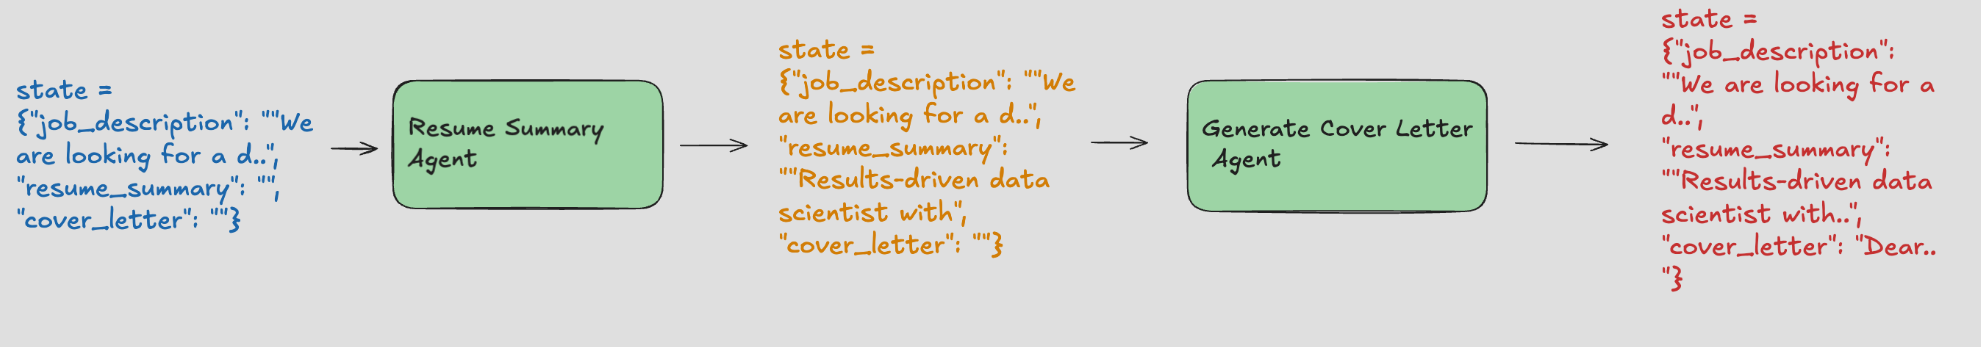



### Resume Summary Agent

In LLM workflows, an "agent" is created through a prompt that gives the LLM specific instructions and persona. The generate_resume_summary node demonstrates this by transforming the LLM into a "resume assistant" through its prompt. This node receives the state containing the job description, processes it using the agent created by the prompt, and returns an updated state with the new resume summary.
Nodes provide the workflow structure while prompts define agent capabilities. The state object serves as shared memory between nodes, allowing each agent to build upon previous work while using the same underlying LLM instance.


In [39]:
def generate_resume_summary(state: ChainState) -> ChainState:
    prompt = f"""
You're a resume assistant. Read the following job description and summarize the key qualifications and experience the ideal candidate should have, phrased as if from the perspective of a strong applicant's resume summary.

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "resume_summary": response.content}

The agent starts with this initial state and passes it to the first node, generate_resume_summary. Inside that function, it can access the job description using ```state['job_description']```, which will serve as the input later on.

When the function returns, it uses Python’s dictionary unpacking syntax: **state**. This means “create a new dictionary that includes all the key-value pairs from the original state dictionary, and then add or update specific keys.” In this case, it updates the "resume_summary" field with the newly generated content.
The state varable would look like this:

```python
state = {
    "job_description": ""We are looking for a data scientist with experience in machine learning, NLP..", 
    "resume_summary": "Results-driven data scientist with expertise in machine learning...",
    "cover_letter": ""
}
```


In [40]:
def generate_cover_letter(state: ChainState) -> ChainState:
    prompt = f"""
You're a cover letter writing assistant. Using the resume summary below, write a professional and personalized cover letter for the following job.

Resume Summary:
{state['resume_summary']}

Job Description:
{state['job_description']}
"""

    response = llm.invoke(prompt)

    return {**state, "cover_letter": response.content}

## LangGraph Workflow 
### Initializing the LangGraph Workflow



This line creates a new `StateGraph` instance and configures it with our `ChainState` definition. This crucial step establishes the workflow's foundation by specifying the structure of data that will flow through the nodes. The `StateGraph` uses the `ChainState` TypedDict to validate data types for each field (`job_description`, `resume_summary`, and `cover_letter`), ensuring proper information passing between nodes. This data contract enables LangGraph to manage state transitions efficiently as the workflow progresses from node to node.


In [41]:
workflow = StateGraph(ChainState)
workflow

We are adding two nodes to our workflow graph. Each node represents a distinct step in the prompt chaining process:

- `"generate_resume_summary"` is the first node, which generates a tailored summary based on the job description.
- `"generate_cover_letter"` is the second node, which uses that summary to create a personalized cover letter.


In [42]:
workflow.add_node("generate_resume_summary", generate_resume_summary)
workflow.add_node("generate_cover_letter", generate_cover_letter)

Setting the **entry point** of the workflow to `"generate_resume_summary"`. This means that when the workflow is executed, it will start with this node.


Now we are defining the **connection between two nodes** by adding an edge from `"generate_resume_summary"` to `"generate_cover_letter"`. This tells the workflow to pass the state from the first node to the second, forming a sequential chain.


In [43]:
workflow.set_entry_point("generate_resume_summary")
workflow.add_edge("generate_resume_summary", "generate_cover_letter")

Now we are marking `"generate_cover_letter"` as the final node, indicating where the workflow should end.


In [44]:
workflow.set_finish_point("generate_cover_letter")

In [45]:
print_workflow_info(workflow)

WORKFLOW INFORMATION
Nodes: {'generate_resume_summary': StateNodeSpec(runnable=generate_resume_summary(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None, trace_policy=None), 'generate_cover_letter': StateNodeSpec(runnable=generate_cover_letter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.ChainState'>, retry_policy=None, cache_policy=None, is_error_handler=False, error_handler_node=None, ends=(), defer=False, timeout=None, trace_policy=None)}
Edges: {('generate_resume_summary', 'generate_cover_letter'), ('__start__', 'generate_resume_summary'), ('generate_cover_letter', '__end__')}
Finish points attribute not directly accessible


In [46]:
#Now we are compiling the workflow into an executable app, which prepares it for running with input data.

app = workflow.compile()

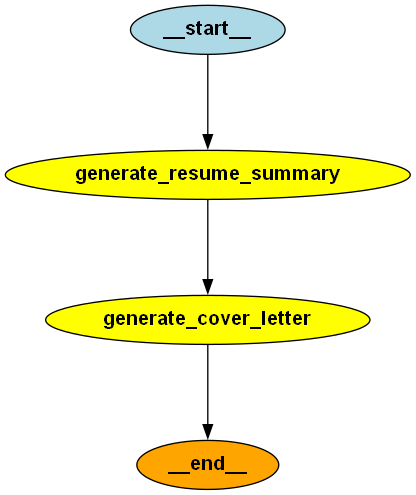

In [47]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In [48]:
# Now we are defining the input for the workflow by providing a job description, and then invoking the compiled app with this input to run the entire prompt chaining process.


input_state = {
        "job_description": "We are looking for a data scientist with experience in machine learning, NLP, and Python. Prior work with large datasets and experience deploying models into production is required."
}

result = app.invoke(input_state)

2026-09-14 19:55:17,874 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
2026-09-14 19:55:36,790 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


In [49]:

# let us see what LLM thinks about how a strong resume should look like for this job description, and then generate a cover letter based on that resume summary.

result['resume_summary']

'This is a highly technical role, so your summary needs to be dense with specific keywords and demonstrate not just knowledge, but *capability* (i.e., you can build and deploy things).\n\nHere is a summary, broken down into bullet points, that you can adapt and integrate into your professional summary or "Skills" section.\n\n***\n\n### 🚀 Suggested Resume Summary Language\n\n**Goal:** To immediately signal that you are a full-cycle data scientist who can handle the entire process, from raw data to live product.\n\n#### 🎯 Core Technical Expertise (The "What I Know")\n\n*   **Machine Learning & NLP:** Deep expertise in developing, training, and optimizing advanced machine learning models, with specialized proficiency in Natural Language Processing (NLP) techniques (e.g., sentiment analysis, entity recognition, text classification).\n*   **Programming Proficiency:** Highly proficient in Python, utilizing key libraries such as Pandas, NumPy, Scikit-learn, and TensorFlow/PyTorch to build sca

### Workflow Pattern: Routing

Routing is a pattern where an LLM (or small router agent) **classifies or interprets incoming input** and then **routes it to the appropriate sub-process** or agent. This design is helpful when you're dealing with **multiple types of tasks or user intents**, and you want specialized logic or handling for each case.

It works like a switchboard — one intelligent node (a classifier or router) analyzes the input and directs it to the correct branch.

#### Use Cases:
- AI customer service bots (route billing, tech support, or general inquiries)
- Multi-skill agents (for example, summarization, translation, and data extraction)
- Adaptive education bots (route to math, science, or grammar modules)

---

#### Routing Techniques:
1. **Hard-coded keyword-based routing** (primitive)
2. **LLM-based routing** using classification prompts
3. **Embedding-based semantic matching** with a routing map

---


### Use Case: Routing — Task Classifier for Summarization and Translation

In this workflow, we are going to build a simple **task router** using the Routing design pattern. The goal is to create a system that can intelligently decide whether the user wants to **summarize** or **translate** a given input, and then send it to the appropriate processing path.

This pattern is useful when the system needs to handle **multiple types of tasks** based on the user’s intent. Instead of creating one large model to handle everything, we let a **router node** classify the request and direct it to a **specialized sub-process**.

For example:
- If the input is “Summarize this article about AI,” the router sends it to the **summarizer**.
- If the input is “Translate this to French,” it sends it to the **translator**.


Now we are defining the `RouterState` using `TypedDict` to represent the shared state in our routing workflow. This state includes:

- `user_input`: the raw input provided by the user,
- `task_type`: the type of task determined by the router (for example, "summarize" or "translate"),
- `output`: the final result generated after routing to the appropriate task handler.


In [50]:
class RouterState(TypedDict):
    user_input: str
    task_type: str
    output: str

Now we are defining the `router_node`, which acts as the decision-maker in the workflow. It sends a prompt to the LLM asking it to classify the user's intent as either `"summarize"` or `"translate"`. The result is stored in the `task_type` field of the state and will determine which processing node the workflow routes to next.


In [51]:


class Router(BaseModel):
    role: str = Field(..., description="Decide whether the user wants to summarize a passage  ouput 'summarize'  or translate text into French oupput translate.")
llm_router=llm.bind_tools([Router])

response=llm_router.invoke("summarize this I love the sun its so warm")



2026-09-14 19:56:03,459 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


In [52]:
import logging
import sys

# Configure global logging to use stdout
logging.basicConfig(
    level=logging.INFO,
    stream=sys.stdout,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

In [53]:

import logging
import sys


# 1. Create a named logger
logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)  # Set the threshold level

# 2. Create a handler that targets stdout
stdout_handler = logging.StreamHandler(sys.stdout)
stdout_handler.setLevel(logging.DEBUG)

# 3. Create a formatter and add it to the handler
formatter = logging.Formatter("%(name)s - %(levelname)s - %(message)s")
stdout_handler.setFormatter(formatter)

# 4. Add the handler to your logger
logger.addHandler(stdout_handler)

In [71]:

def router_node(state: RouterState) -> RouterState:
    routing_prompt = f"""
    You are an AI task classifier.

    Decide whether the user wants to:
    - "summarize" a passage
    - or "translate" text into French

    Respond with just one word: 'summarize' or 'translate'.

    User Input: "{state['user_input']}"
    """
    response = llm_router.invoke(routing_prompt)

    logger.debug("-----------response------------")
    print("-----------response------------")
    logger.debug(response)

    tool_calls = getattr(response, "tool_calls", None) or []
    if tool_calls:
        first_call = tool_calls[0]
        if isinstance(first_call, dict):
            task_type = first_call.get("args", {}).get("role")
        else:
            task_type = getattr(first_call, "args", {}).get("role")
    else:
        task_type = str(response.content).strip().lower()

    if task_type not in {"summarize", "translate"}:
        task_type = task_type.replace("\n", " ").strip().lower()
        if task_type.startswith("summarize"):
            task_type = "summarize"
        elif task_type.startswith("translate"):
            task_type = "translate"
        else:
            raise ValueError(f"Unexpected router output: {response}")

    return {**state, "task_type": task_type}

Now we are defining the `router` function, which simply returns the `task_type` from the state. This value will be used by LangGraph to decide which node to route to next based on the classification result.


In [55]:
def router(state: RouterState) -> str:
    return state['task_type']

Now we are defining the `summarize_node`, which is responsible for summarizing the user's input. It prompts the LLM to generate a concise summary and stores the result in the `output` field, while also confirming the `task_type` as `"summarize"`.


In [56]:
def summarize_node(state: RouterState) -> RouterState:
    prompt = f"Please summarize the following passage:\n\n{state['user_input']}"
    response = llm.invoke(prompt)
    
    return {**state, "task_type": "summarize", "output": response.content}

Now we are defining the `translate_node`, which handles translation tasks. It prompts the LLM to translate the user's input into French and saves the translated text in the `output` field, while also updating the `task_type` to `"translate"`.


In [57]:
def translate_node(state: RouterState) -> RouterState:
    prompt = f"Translate the following text to French:\n\n{state['user_input']}"
    response = llm.invoke(prompt)

    return {**state, "task_type": "translate", "output": response.content}

Now we are initializing a new `StateGraph` using the `RouterState` type. This sets up the structure of our routing workflow and defines the schema for the state that will be passed between nodes.


In [58]:
workflow = StateGraph(RouterState)


Now we are adding three nodes to the workflow:

- `"router"`: the node that classifies the user input,  
- `"summarize"`: the node that handles summarization,  
- `"translate"`: the node that handles translation.  


In [59]:
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)

In [60]:
# Now we are setting `"router"` as the entry point of the workflow, meaning the execution will start by classifying the user’s intent.

workflow.set_entry_point("router")

Now we are adding conditional edges from the `"router"` node based on the value returned by the `router` function. If the task is `"summarize"`, the workflow routes to the `summarize` node; if it's `"translate"`, it routes to the `translate` node.


In [61]:
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})

In [62]:
# Now we are marking both `"summarize"` and `"translate"` as valid finish points. This means the workflow can end after executing either node, depending on the task type selected by the router.

workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")

In [63]:
# We compile the workflow into an executable app using the `compile()` method. This step prepares the defined nodes and routing logic so the workflow can be run with actual input data.

app = workflow.compile()



To better understand the structure of our workflow, we use `app.get_graph().draw_png()` to generate a visual representation of the graph. This diagram helps us verify how nodes are connected and where conditional routing decisions lead within the workflow.


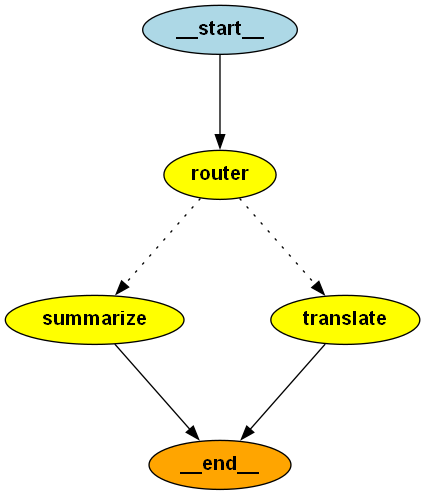

In [64]:
from IPython.display import Image, display

# Generate a visualization of the workflow graph
display(Image(app.get_graph().draw_png()))

In this step, we provide a minimal input containing only the `user_input` field. Since the state is defined using `TypedDict`, missing fields such as `task_type` and `output` will be automatically handled during execution. We then invoke the app with this input, which starts the routing process and executes the appropriate task based on the user's intent.


In [74]:
# Rebuild the graph so the notebook uses the current router logic.
workflow = StateGraph(RouterState)
workflow.add_node("router", router_node)
workflow.add_node("summarize", summarize_node)
workflow.add_node("translate", translate_node)
workflow.set_entry_point("router")
workflow.add_conditional_edges("router", router, {
    "summarize": "summarize",
    "translate": "translate"
})
workflow.set_finish_point("summarize")
workflow.set_finish_point("translate")
app = workflow.compile()

input_text = {
    "user_input": "Can you translate this sentence: I love programming?"
}

result = app.invoke(input_text)
result

2026-09-14 20:06:49,474 - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
__main__ - DEBUG - -----------response------------
__main__ - DEBUG - -----------response------------
2026-09-14 20:06:52,587 - DEBUG - -----------response------------
-----------response------------
__main__ - DEBUG - content='translate' additional_kwargs={} response_metadata={'model': 'gemma4', 'created_at': '2026-09-15T03:06:52.5854472Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3494028300, 'load_duration': 5883800, 'prompt_eval_count': 152, 'prompt_eval_duration': 258117000, 'eval_count': 169, 'eval_duration': 3183633000, 'logprobs': None, 'model_name': 'gemma4', 'model_provider': 'ollama'} id='lc_run--01a0a308-0d81-7650-afd5-b9d1f7ee96ac-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 152, 'output_tokens': 169, 'total_tokens': 321}
__main__ - DEBUG - content='translate' additional_kwargs={} response_metadata={'model': 'gemma4', 'created_at': '2

{'user_input': 'Can you translate this sentence: I love programming?',
 'task_type': 'translate',
 'output': 'The most natural and common translation is:\n\n**J\'aime la programmation.**\n\n***\n\n### Pronunciation Guide:\n\n*   **J\'aime:** *zhem* (The \'J\' sounds like the \'s\' in \'measure\')\n*   **la:** *lah*\n*   **programmation:** *pro-gra-ma-syon*\n\n***\n\n### 💡 Context Note:\n\nIf you wanted to emphasize that you are *passionate* about it (a stronger feeling than just "I like"), you could say:\n\n**Je suis passionné(e) par la programmation.**\n*(Use **passionné** if you are male, and **passionnée** if you are female.)*'}

In [75]:
print(result[ 'output'])
print(result['task_type'])

The most natural and common translation is:

**J'aime la programmation.**

***

### Pronunciation Guide:

*   **J'aime:** *zhem* (The 'J' sounds like the 's' in 'measure')
*   **la:** *lah*
*   **programmation:** *pro-gra-ma-syon*

***

### 💡 Context Note:

If you wanted to emphasize that you are *passionate* about it (a stronger feeling than just "I like"), you could say:

**Je suis passionné(e) par la programmation.**
*(Use **passionné** if you are male, and **passionnée** if you are female.)*
translate


### Workflow Pattern: Parallelization

Parallelization is a pattern where **multiple LLM tasks are executed at the same time** instead of one after another. This is useful when different parts of the task can be done **independently**, allowing for faster processing and better system throughput.

Think of it like a kitchen where one chef is chopping vegetables, another is boiling pasta, and another is baking — all at once. None of them need to wait for the other to finish.

In AI workflows, this means breaking a problem into parts and running them **in parallel**, then collecting and combining the outputs.

#### Use Cases:
- Summarizing different sections of a large document simultaneously
- Translating a batch of user messages at once
- Generating multiple variations of an ad copy or product description
- Running safety checks using different prompts and comparing outputs
- Ensembling results from different models or prompts for consensus

---

#### Parallelization Techniques:
1. **Format Diversity (Multi-Output Tasks)**  
   - Run the **same input** through **different prompt styles, languages, or output formats**  
   - Each LLM call produces a distinct kind of result in parallel  
   - Combine all outputs into a unified response  
   - *Example:* Translate a sentence into French, Spanish, and Japanese at the same time

2. **Task Splitting (Sectioning)**  
   - Divide a large input into smaller parts  
   - Run each part through the same task (for example, summarization) in parallel  
   - Merge the partial results for a final outcome  
   - *Example:* Summarize each paragraph of an article simultaneously

3. **Consensus Voting (Multi-Agent Evaluation)**  
   - Run the **same task** multiple times with different agents or prompt styles  
   - Compare the responses and choose the best one via ranking or majority vote  
   - *Example:* Ask 3 variations of a model to write a safe response and pick the most appropriate one
